# KPI Analysis – Customer Satisfaction

This notebook analyzes customer satisfaction based on review scores and examines how delivery performance is associated with customer reviews.

In [2]:
import pandas as pd
import sys

print("Python:", sys.version)
print("Pandas:", pd.__version__)

Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
Pandas: 2.3.3


In [3]:
from pathlib import Path

data_path = Path("../data")

csv_files = list(data_path.glob("*.csv"))

for file in csv_files:
    print(file.name)

In [4]:
from pathlib import Path
print(Path.cwd())

c:\Users\user777\Desktop\Conclusion Intelegence project\SpikupCapstone2026_CYRV\notebooks


In [5]:
data_path = Path("../data")

print("Data folder exists:", data_path.exists())

for item in data_path.iterdir():
    print(item.name)

Data folder exists: True
cyrv
README.md


In [6]:
data_path = Path("../data/cyrv")

csv_files = list(data_path.glob("*.csv"))

for file in csv_files:
    print(file.name)

CYRV_customers_dataset.csv
CYRV_geolocation_dataset.csv
CYRV_orders_dataset.csv
CYRV_order_items_dataset.csv
CYRV_order_payments_dataset.csv
CYRV_order_reviews_dataset.csv
CYRV_products_dataset.csv
CYRV_sellers_dataset.csv
product_category_name_translation.csv


In [7]:
file_info = []

for file in csv_files:
    file_info.append({
        "file": file.name,
        "size_mb": round(file.stat().st_size / (1024 * 1024), 2)
    })

pd.DataFrame(file_info).sort_values("size_mb", ascending=False)

,file,size_mb
1,CYRV_geolocation_dataset.csv,59.39
2,CYRV_orders_dataset.csv,16.93
3,CYRV_order_items_dataset.csv,14.83
5,CYRV_order_reviews_dataset.csv,13.78
0,CYRV_customers_dataset.csv,8.71
4,CYRV_order_payments_dataset.csv,5.61
6,CYRV_products_dataset.csv,2.30
7,CYRV_sellers_dataset.csv,0.17
8,product_category_name_translation.csv,0.00


In [8]:
customers = pd.read_csv(data_path / "CYRV_customers_dataset.csv")
orders = pd.read_csv(data_path / "CYRV_orders_dataset.csv")
order_items = pd.read_csv(data_path / "CYRV_order_items_dataset.csv")
payments = pd.read_csv(data_path / "CYRV_order_payments_dataset.csv")
reviews = pd.read_csv(data_path / "CYRV_order_reviews_dataset.csv")
products = pd.read_csv(data_path / "CYRV_products_dataset.csv")
sellers = pd.read_csv(data_path / "CYRV_sellers_dataset.csv")
category_translation = pd.read_csv(
    data_path / "product_category_name_translation.csv"
)

print("Datasets loaded successfully ✅")

Datasets loaded successfully ✅


In [9]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [10]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [11]:

# Prepare delivered orders for Customer Satisfaction Analysis

delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

# Calculate actual delivery duration
delivered_orders["actual_delivery_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

# Calculate delay using calendar dates
delivered_orders["delay_days"] = (
    delivered_orders["order_delivered_customer_date"].dt.normalize()
    - delivered_orders["order_estimated_delivery_date"].dt.normalize()
).dt.days

# Define on-time delivery using calendar dates
delivered_orders["on_time"] = (
    delivered_orders["order_delivered_customer_date"].dt.normalize()
    <= delivered_orders["order_estimated_delivery_date"].dt.normalize()
)

# Summary
print("Delivered orders:", len(delivered_orders))

print(
    "Average actual delivery days:",
    round(delivered_orders["actual_delivery_days"].mean(), 2)
)

print(
    "On-time delivery rate:",
    round(delivered_orders["on_time"].mean() * 100, 2),
    "%"
)

print(
    "Late delivery rate:",
    round((~delivered_orders["on_time"]).mean() * 100, 2),
    "%"
)

print(
    "Late orders:",
    (~delivered_orders["on_time"]).sum()
)


Delivered orders: 96478
Average actual delivery days: 12.56
On-time delivery rate: 93.22 %
Late delivery rate: 6.78 %
Late orders: 6542


In [18]:
delivery_reviews = delivered_orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

review_comparison = (
    delivery_reviews
    .groupby("on_time")
    .agg(
        number_of_orders=("order_id", "count"),
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

review_comparison["delivery_status"] = review_comparison["on_time"].map({
    True: "On time",
    False: "Late"
})

review_comparison[
    ["delivery_status", "number_of_orders", "average_review_score"]
]

,delivery_status,number_of_orders,average_review_score
0,Late,6417,2.273804
1,On time,89944,4.289980


In [13]:
delivery_reviews["delivery_status"] = delivery_reviews["on_time"].replace({
    True: "On time",
    False: "Late"
})

review_distribution = pd.crosstab(
    delivery_reviews["review_score"],
    delivery_reviews["delivery_status"],
    normalize="columns"
) * 100

review_distribution.round(2)

delivery_status,Late,On time
review_score,,
1,53.69,6.63
2,8.66,2.65
3,10.86,8.08
4,10.16,20.38
5,16.63,62.26


In [19]:
late_with_reviews = delivery_reviews[
    (delivery_reviews["on_time"] == False) &
    (delivery_reviews["delay_days"].notna())
].copy()

late_with_reviews["delay_group"] = pd.cut(
    late_with_reviews["delay_days"],
    bins=[0, 3, 7, 14, 30, float("inf")],
    labels=["1-3 days", "4-7 days", "8-14 days", "15-30 days", "30+ days"],
    include_lowest=True
)

delay_review_summary = (
    late_with_reviews
    .groupby("delay_group", observed=False)
    .agg(
        number_of_orders=("order_id", "count"),
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

delay_review_summary

,delay_group,number_of_orders,average_review_score
0,1-3 days,1856,3.289871
1,4-7 days,1756,2.104214
2,8-14 days,1452,1.676309
3,15-30 days,1014,1.617357
4,30+ days,331,2.054381


In [20]:
delay_star_distribution = pd.crosstab(
    late_with_reviews["delay_group"],
    late_with_reviews["review_score"],
    normalize="index"
) * 100

delay_star_distribution.round(2)

review_score,1,2,3,4,5
delay_group,,,,,
1-3 days,25.16,7.00,14.66,20.04,33.14
4-7 days,58.54,9.11,9.85,8.37,14.12
8-14 days,70.39,9.64,8.88,4.13,6.96
15-30 days,70.81,10.85,9.17,4.14,5.03
30+ days,63.14,4.83,9.06,9.37,13.60


## Customer Satisfaction Findings

- On-time deliveries received a significantly higher average review score (4.29) compared to late deliveries (2.27).
- Customer satisfaction generally decreases as delivery delays become longer.
- For delays of 1–3 days, 25.16% of reviews were 1-star, compared with 58.54% for delays of 4–7 days and 70.81% for delays of 15–30 days.
- The average review score decreased from 3.29 for delays of 1–3 days to 1.62 for delays of 15–30 days.
- For delays exceeding 30 days, the average review score increased slightly to 2.05, although 63.14% of reviews were still 1-star.
- These results indicate a strong association between delivery delays and lower customer satisfaction.

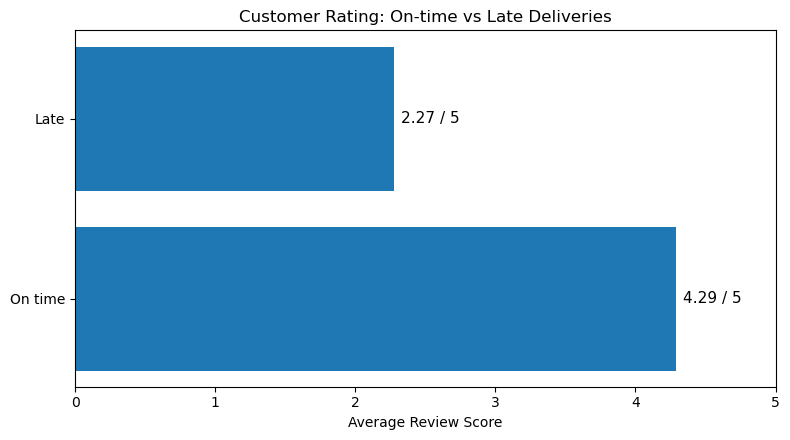

In [21]:
import matplotlib.pyplot as plt

rating_plot = review_comparison[
    ["delivery_status", "average_review_score"]
].copy()

# Put On time first
rating_plot["delivery_status"] = pd.Categorical(
    rating_plot["delivery_status"],
    categories=["On time", "Late"],
    ordered=True
)

rating_plot = rating_plot.sort_values("delivery_status")

plt.figure(figsize=(8, 4.5))

bars = plt.barh(
    rating_plot["delivery_status"],
    rating_plot["average_review_score"]
)

plt.xlim(0, 5)
plt.xlabel("Average Review Score")
plt.ylabel("")
plt.title("Customer Rating: On-time vs Late Deliveries")

for bar, value in zip(bars, rating_plot["average_review_score"]):
    plt.text(
        value + 0.05,
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f} / 5",
        va="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

#Late deliveries are associated with substantially lower customer satisfaction. The average review score drops from 4.29 for on-time deliveries to 2.27 for late deliveries.

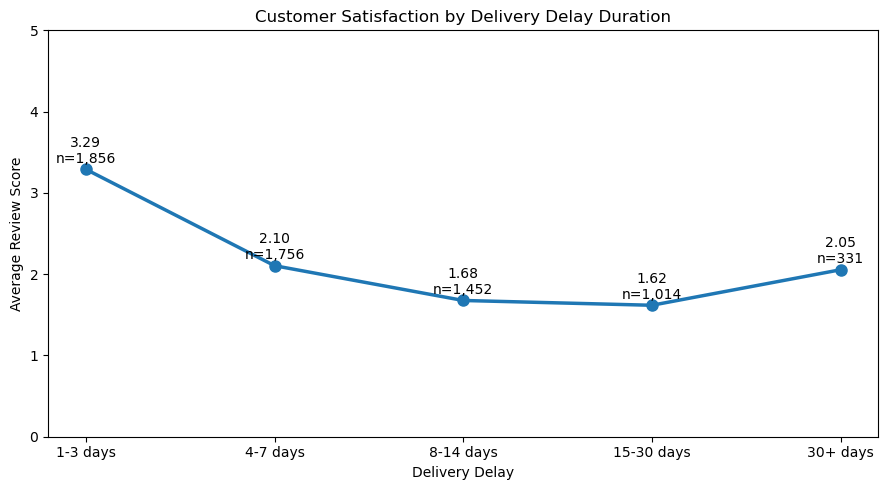

In [22]:

import matplotlib.pyplot as plt

# Customer satisfaction by delivery delay group
# Use actual order counts from the summary table
order_counts = delay_review_summary["number_of_orders"].tolist()

plt.figure(figsize=(9, 5))

plt.plot(
    delay_review_summary["delay_group"].astype(str),
    delay_review_summary["average_review_score"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

# Add average rating and number of orders
for x, y, count in zip(
    delay_review_summary["delay_group"].astype(str),
    delay_review_summary["average_review_score"],
    order_counts
):
    plt.text(
        x,
        y + 0.08,
        f"{y:.2f}\nn={count:,}",
        ha="center",
        fontsize=10
    )

plt.ylim(0, 5)
plt.xlabel("Delivery Delay")
plt.ylabel("Average Review Score")
plt.title("Customer Satisfaction by Delivery Delay Duration")

plt.tight_layout()
plt.show()


### Insight


Customer satisfaction generally decreases as delivery delays increase. The average review score drops from 3.29 for delays of 1–3 days to 1.62 for delays of 15–30 days, before rising slightly to 2.05 for delays exceeding 30 days.

## Business Recommendations

- **Prioritize on-time delivery**, as late deliveries are strongly associated with lower customer satisfaction and review scores.

- **Monitor orders at risk of delay** and take proactive action to prevent late deliveries and minimize their impact on customer experience.

- **Focus improvement efforts on delays of 8–30 days**, particularly the 15–30 day group, which recorded the lowest average customer review score (1.62/5).

- **Combine delivery performance metrics with customer review scores** to identify logistics and operational issues, prioritize improvements, and enhance overall customer satisfaction.